### Tareas

- Diagrama entidad relacion (Daro)
- Analisis exploratorio de los datos (Pablo y Ana)
- Propuesta de indicadores + prototipo de dashboard (Noe y Esteban)

# 0. Librerias

In [1]:
# Manejo de archivos y operaciones matemáticas
import math
import os

# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Constantes
from  constants import DATA_RAW


# 1. Ingesta de datos 

In [2]:
df = pd.read_csv(DATA_RAW)

# 2. Exploración inicial (Initial EDA)

In [19]:
import sweetviz as sv

report = sv.analyze(df)
report.show_html()

c:\Users\Usuario\Desktop\HR REPO\HR-Analytics\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Reviso Estrucutra

In [4]:
df.head(5)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8,Active,On-site,92992.0,2023,Germany,Munich,32,Mid
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15,Active,On-site,111121.0,2016,Spain,Seville,43,Senior
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1,Active,Hybrid,49012.0,2024,France,Marseille,23,Junior
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2,Active,On-site,57553.0,2024,United Kingdom,Edinburgh,31,Junior


In [5]:
df.tail(5)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
1999995,EMP1999996,Ottmar Kusch-Dörschner,IT,Software Developer,2020-11-30,Good,15,Active,Hybrid,136684.0,2020,Germany,Frankfurt,44,Senior
1999996,EMP1999997,Isis Wagenvoort,Sales,Sales Manager,2024-06-06,Good,3,Active,On-site,57911.0,2024,Netherlands,Amsterdam,25,Junior
1999997,EMP1999998,Ángel Gomez Arenas,Sales,Sales Manager,2020-05-21,Excellent,14,Active,Remote,146065.0,2020,Spain,Valencia,39,Senior
1999998,EMP1999999,Carmela Weiß,Sales,Business Development,2018-07-11,Excellent,9,Active,Remote,138855.0,2018,Germany,Frankfurt,35,Senior
1999999,EMP2000000,Macario Casals,IT,Software Developer,2025-09-11,Good,1,Active,Hybrid,46067.0,2025,Spain,Madrid,28,Junior


In [6]:
df.columns

Index(['Employee_ID', 'Full_Name', 'Department', 'Job_Title', 'Hire_Date',
       'Performance_Rating', 'Experience_Years', 'Status', 'Work_Mode',
       'Salary', 'Year', 'Country', 'City', 'Age', 'Job_Level'],
      dtype='object')

In [7]:
df.shape

(2000000, 15)

In [8]:
df.dtypes

Employee_ID            object
Full_Name              object
Department             object
Job_Title              object
Hire_Date              object
Performance_Rating     object
Experience_Years        int64
Status                 object
Work_Mode              object
Salary                float64
Year                    int64
Country                object
City                   object
Age                     int64
Job_Level              object
dtype: object

In [9]:
# Revisar con el equipo  -- Dejo esto para futuro diccionario  de arreglo de tipos
"""
Employee_ID               str
Full_Name                 str
Department                str
Job_Title                 str
Hire_Date                 str YYYY/MM/DD --| Datetime
Performance_Rating        str
Experience_Years        int64
Status                    str
Work_Mode                 str
Salary                float64 
Year                    int64  --| Lo dejamos asi?
Country                   str
City                      str
Age                     int64
Job_Level                 str

"""

'\nEmployee_ID               str\nFull_Name                 str\nDepartment                str\nJob_Title                 str\nHire_Date                 str YYYY/MM/DD --| Datetime\nPerformance_Rating        str\nExperience_Years        int64\nStatus                    str\nWork_Mode                 str\nSalary                float64 \nYear                    int64  --| Lo dejamos asi?\nCountry                   str\nCity                      str\nAge                     int64\nJob_Level                 str\n\n'

## Revision de Nulos 

In [10]:
df.isnull().sum().sort_values(ascending=False)


Performance_Rating    3333
Employee_ID              0
Full_Name                0
Department               0
Job_Title                0
Hire_Date                0
Experience_Years         0
Status                   0
Work_Mode                0
Salary                   0
Year                     0
Country                  0
City                     0
Age                      0
Job_Level                0
dtype: int64

Reviso si existe algun otro tipo de nulo que este formateado como un string nan,0,-

In [11]:
columns=['Department', 'Job_Title', 
       'Performance_Rating', 'Experience_Years', 'Status', 'Work_Mode',
       'Salary', 'Year', 'Country', 'City', 'Age', 'Job_Level']

for col in columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False))
    print("-------------------------------------------")


 Department
Department
Sales         600633
IT            499325
Operations    400595
Finance       299955
HR            199492
Name: count, dtype: int64
-------------------------------------------

 Job_Title
Job_Title
Sales Manager           120595
Sales Executive         120349
Sales Director          119971
Regional Lead           119886
Business Development    119832
IT Manager              100132
System Admin            100103
DevOps Engineer          99886
Data Engineer            99747
Software Developer       99457
Operations Director      80346
Logistics                80242
Operations Manager       80119
Supply Chain             80025
Operations Analyst       79863
Accountant               60125
Tax Specialist           60050
Financial Analyst        60017
CFO                      59921
Finance Manager          59842
HR Coordinator           40070
HR Manager               39989
HR Director              39887
Talent Specialist        39848
Recruiter                39698
Name

REVISAR CON EL EQUIPO: 
Resumen de análisis de nulos 

1) Performance_Rating  --- 3333 Null values
2) años de experiencia negativos
3) Salarios negativos y atipicos revisar
4) Experience years negativos

## Revision de Duplicados

In [12]:
# Reviso si hay filas duplicadas 
df[df.duplicated(keep=False)]

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level


In [13]:
# Reviso si hay Ids duplicados
df[df.duplicated(subset=["Employee_ID"], keep=False)].sort_values(by="Employee_ID")


,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level


In [14]:
# ver empleados duplicados
df[df.duplicated(subset=["Full_Name"], keep=False)].sort_values("Full_Name")

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
1613661,EMP1613662,Aaliyah Ansems,IT,Software Developer,2020-01-08,Good,1,Active,On-site,59408.0,2020,Netherlands,The Hague,30,Junior
1233693,EMP1233694,Aaliyah Ansems,IT,Data Engineer,2022-11-26,Good,2,Active,Remote,53005.0,2022,Netherlands,Amsterdam,25,Junior
1651398,EMP1651399,Aaliyah Arens,Sales,Sales Executive,2023-05-31,Excellent,6,Active,On-site,96787.0,2023,Netherlands,Amsterdam,28,Mid
1858581,EMP1858582,Aaliyah Arens,Operations,Operations Analyst,2025-09-30,Excellent,0,Active,Hybrid,50928.0,2025,Netherlands,Eindhoven,21,Junior
979926,EMP0979927,Aaliyah Bresse,Operations,Logistics,2023-10-21,Good,4,Active,On-site,90978.0,2023,Netherlands,Utrecht,31,Mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086330,EMP1086331,Łukasz Sugier,IT,DevOps Engineer,2025-08-14,Excellent,3,Active,Hybrid,56234.0,2025,Poland,Warsaw,23,Junior
1272116,EMP1272117,Łukasz Swiątek,IT,IT Manager,2018-08-09,Excellent,11,Active,On-site,138440.0,2018,Poland,Warsaw,31,Senior
1974494,EMP1974495,Łukasz Swiątek,Operations,Operations Manager,2025-06-06,Satisfactory,2,Active,Remote,40386.0,2025,Poland,Warsaw,25,Junior
1229255,EMP1229256,Łukasz Wójcikiewicz,Operations,Operations Analyst,2025-01-18,Satisfactory,6,Active,On-site,93919.0,2025,Poland,Krakow,33,Mid


REVISAR: Hablar con el equipo de las reglas de negocio para poder avanzar con el tema de logicas. Revisar con Ana los sueldos para ver si existe alguna inconsistencia 

## 5. Outliers

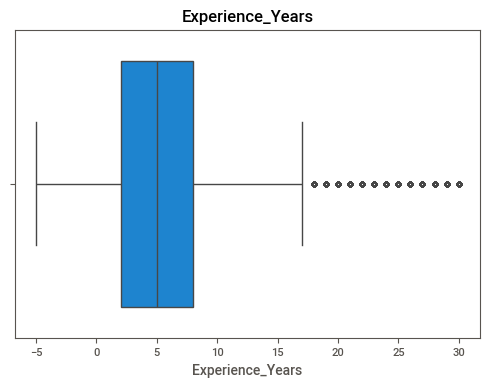

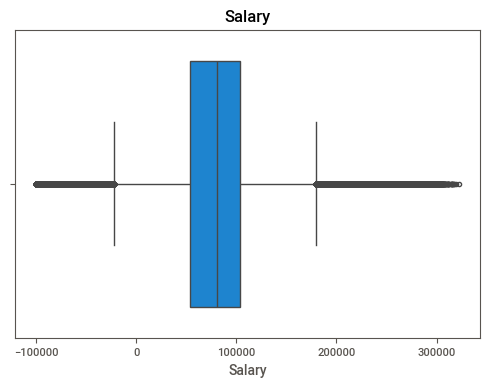

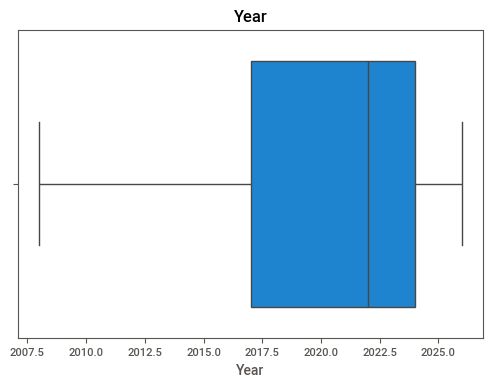

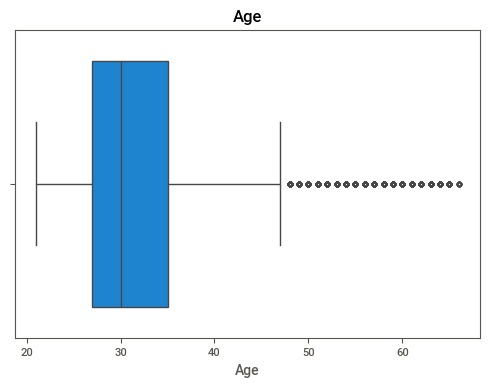

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col}")
    plt.show()

## 6. Inconsistencia logica

In [54]:
errors = {}

# Salarios Negativos (< 0)
errors["Salarios_Negativos"] = df[df["Salary"] < 0]

# Inactivos con salarios 
errors["Inactivos_con_Salario"] = df[(df["Status"] != "Active") & (df["Salary"] > 0)]

# Activos con salario 0 
errors["Activos_con_Salario_nulo"] = df[(df["Status"] == "Active") & (df["Salary"] == 0)]


# Años de experiencia negativa  (< 0)
errors["Años_Exp_Negativa"] = df[df["Experience_Years"] < 0]

# Edad invalida (< 0)
errors["Edad_Invalida"] = df[(df["Age"] < 18) | (df["Age"] > 70)]

# Experiencia es mayor que los posibles años laborales 
errors["Exp_mayor_edad"] = df[df["Experience_Years"] > df["Age"] - 18]

for k, v in errors.items():
    print(f"{k}: {len(v)} ({len(v)/len(df)*100:.2f}%)")

Salarios_Negativos: 3333 (0.17%)
Inactivos_con_Salario: 206065 (10.30%)
Activos_con_Salario_nulo: 0 (0.00%)
Años_Exp_Negativa: 2421 (0.12%)
Edad_Invalida: 0 (0.00%)
Exp_mayor_edad: 0 (0.00%)


In [55]:
errors["Salarios_Negativos"]

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
497,EMP0000498,Marc Davies,Sales,Sales Manager,2015-06-12,Excellent,7,Active,Remote,-86735.0,2015,United Kingdom,Leeds,35,Mid
2928,EMP0002929,Pepito Agudo Garmendia,Operations,Operations Manager,2018-05-15,Good,10,Active,On-site,-44850.0,2018,Spain,Barcelona,36,Senior
3906,EMP0003907,Constance-Renée Roger,IT,System Admin,2011-07-26,Good,2,Active,On-site,-35243.0,2011,France,Nice,28,Junior
8074,EMP0008075,Ilaria Volterra,Sales,Sales Director,2021-07-07,Satisfactory,8,Active,On-site,-19876.0,2021,Italy,Venice,31,Mid
8596,EMP0008597,Louis Michaud,Sales,Sales Executive,2024-08-29,Satisfactory,7,Active,Hybrid,-7143.0,2024,France,Paris,29,Mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997550,EMP1997551,Valentine Schomber,Sales,Sales Director,2024-04-27,Good,1,Active,Remote,-4795.0,2024,Germany,Berlin,25,Junior
1998155,EMP1998156,Ian Köster-Schroeff,IT,DevOps Engineer,2023-12-01,Satisfactory,5,Active,Hybrid,-38227.0,2023,Netherlands,Rotterdam,32,Mid
1999679,EMP1999680,Amico Zetticci,Finance,Finance Manager,2024-05-18,Needs Improvement,8,Active,Hybrid,-44665.0,2024,Italy,Rome,35,Mid
1999763,EMP1999764,María Ángeles Cuevas-Caro,Sales,Sales Executive,2026-01-27,Good,0,Resigned,Hybrid,-32546.0,2026,Spain,Madrid,22,Junior


In [56]:
errors["Inactivos_con_Salario"]

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
11,EMP0000012,Lisanne van 't Erve,HR,Talent Specialist,2022-10-11,Good,4,Resigned,On-site,70116.0,2022,Netherlands,The Hague,27,Mid
14,EMP0000015,Nigel Edwards,Sales,Sales Manager,2023-11-18,Good,0,Resigned,On-site,44369.0,2023,United Kingdom,Leeds,24,Junior
15,EMP0000016,Abdul Burton-Patterson,Operations,Operations Manager,2021-06-27,Good,0,Resigned,Hybrid,46388.0,2021,United Kingdom,London,27,Junior
26,EMP0000027,Miss Olivia Bryan,Operations,Operations Director,2024-11-02,Good,1,Terminated,On-site,40523.0,2024,United Kingdom,Edinburgh,25,Junior
70,EMP0000071,Ciriaco Morillo Moles,HR,HR Director,2021-06-21,Excellent,0,Resigned,Remote,42964.0,2021,Spain,Seville,23,Junior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999955,EMP1999956,Xavier Tessier,Finance,Tax Specialist,2025-11-03,Good,3,Resigned,Remote,43324.0,2025,France,Paris,26,Junior
1999964,EMP1999965,Sébastien Guyon-Perez,Operations,Operations Analyst,2022-08-11,Good,13,Resigned,On-site,119366.0,2022,France,Nice,40,Senior
1999971,EMP1999972,Ida Semitecolo,Finance,Tax Specialist,2021-02-19,Needs Improvement,6,Terminated,On-site,104701.0,2021,Italy,Venice,30,Mid
1999978,EMP1999979,Mrs Patricia Knowles,Operations,Operations Director,2022-12-15,Excellent,1,Resigned,Remote,38884.0,2022,United Kingdom,Edinburgh,28,Junior


In [57]:
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])
df[df["Hire_Date"].dt.year > df["Year"]].shape[0]

0

## Revision de los salarios 

In [68]:
# Chicos aca le voy a meter una imputacion para ver el tema de los salarios, porque me esta nublando los nulos y negativos. Asi mismo, despues comentenlo

# Los negativos los transformo en nan
df.loc[df['Salary'] <= 0, 'Salary'] = np.nan

#Aplico la mediana a los nana del mismo area y nivel
df['Salary'] = df['Salary'].fillna(df.groupby(['Job_Level', 'Department'])['Salary'].transform('median'))

#relleno por si falta alguno que no tenga mediana comaparablecon la meda del df
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [69]:
# Aca agrupe los salarios por nivel de trabajo y departamento y me puse a ver que tan lejos estaban de la media (Preguntar a Noemi sobre esto estadistico)
# Puso un z score de desvio y respecto a eso fue que voy a ver cuales son los outliers. En funcion de eso mi duda es que hacemos con esto jajaja como regla de negocio que comprendemos 
group_cols = ["Job_Level", "Department"]

df["salary_mean"] = df.groupby(group_cols)["Salary"].transform("mean")
df["salary_std"] = df.groupby(group_cols)["Salary"].transform("std")

# Z-score (distancia en desviaciones estándar)
df["salary_zscore"] = (df["Salary"] - df["salary_mean"]) / df["salary_std"]
df

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level,salary_mean,salary_std,salary_zscore
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8,Active,On-site,92992.0,2023,Germany,Munich,32,Mid,87522.193842,8298.767684,0.659111
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior,117702.049993,12828.734564,-0.419687
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15,Active,On-site,111121.0,2016,Spain,Seville,43,Senior,117702.049993,12828.734564,-0.512993
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1,Active,Hybrid,49012.0,2024,France,Marseille,23,Junior,47113.181245,5171.022259,0.367204
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2,Active,On-site,57553.0,2024,United Kingdom,Edinburgh,31,Junior,50659.460173,6048.356252,1.139738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,EMP1999996,Ottmar Kusch-Dörschner,IT,Software Developer,2020-11-30,Good,15,Active,Hybrid,136684.0,2020,Germany,Frankfurt,44,Senior,149164.674241,14971.960218,-0.833603
1999996,EMP1999997,Isis Wagenvoort,Sales,Sales Manager,2024-06-06,Good,3,Active,On-site,57911.0,2024,Netherlands,Amsterdam,25,Junior,50659.460173,6048.356252,1.198927
1999997,EMP1999998,Ángel Gomez Arenas,Sales,Sales Manager,2020-05-21,Excellent,14,Active,Remote,146065.0,2020,Spain,Valencia,39,Senior,143509.452250,14860.660543,0.171967
1999998,EMP1999999,Carmela Weiß,Sales,Business Development,2018-07-11,Excellent,9,Active,Remote,138855.0,2018,Germany,Frankfurt,35,Senior,143509.452250,14860.660543,-0.313206


In [66]:
# Dudas : Tengo dudas porque no se si estoy tomando la inflacion de la moneda puede que el salario cambie año a año para el mismo puesto 
# Consultar con el equipo
outliers = df[df["salary_zscore"].abs() > 2]
outliers


,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level,salary_mean,salary_std,salary_zscore
24,EMP0000025,Herr Theodor Knappe B.Sc.,Finance,Financial Analyst,2012-01-18,Good,28,Active,Remote,311139.0,2012,Germany,Munich,58,Director,240439.053420,24070.483339,2.937205
53,EMP0000054,Sig.ra Margherita Barracco,Sales,Sales Director,2025-06-13,Good,3,Active,Remote,62850.0,2025,Italy,Rome,30,Junior,50659.460173,6048.356252,2.015513
110,EMP0000111,Sonja Hoffmann B.Sc.,IT,IT Manager,2018-04-30,Satisfactory,4,Active,Hybrid,75247.0,2018,Germany,Berlin,30,Mid,92827.097315,8391.999249,-2.094864
126,EMP0000127,Arnaldo Gentili,Sales,Regional Lead,2022-02-19,Good,7,Resigned,Remote,106183.0,2022,Italy,Venice,33,Mid,87522.193842,8298.767684,2.248624
160,EMP0000161,Dipl.-Ing. Nuray Liebelt MBA.,Sales,Business Development,2022-07-31,Good,2,Active,On-site,63084.0,2022,Germany,Hamburg,28,Junior,50659.460173,6048.356252,2.054201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999317,EMP1999318,Ann Morgan,Operations,Operations Analyst,2017-06-04,Needs Improvement,14,Active,Remote,162440.0,2017,United Kingdom,Birmingham,41,Senior,133738.833446,13765.999171,2.084932
1999532,EMP1999533,Natalie Willis,HR,Recruiter,2021-09-30,Good,1,Active,On-site,33881.0,2021,United Kingdom,Birmingham,22,Junior,43077.419519,4585.522345,-2.005534
1999764,EMP1999765,Rosie Smith,IT,System Admin,2024-06-30,Excellent,5,Active,Hybrid,75538.0,2024,United Kingdom,Manchester,26,Mid,92827.097315,8391.999249,-2.060188
1999832,EMP1999833,Philip Coles,HR,HR Coordinator,2025-12-27,Good,4,Active,On-site,55311.0,2025,United Kingdom,Birmingham,25,Mid,68914.437227,6611.914679,-2.057413


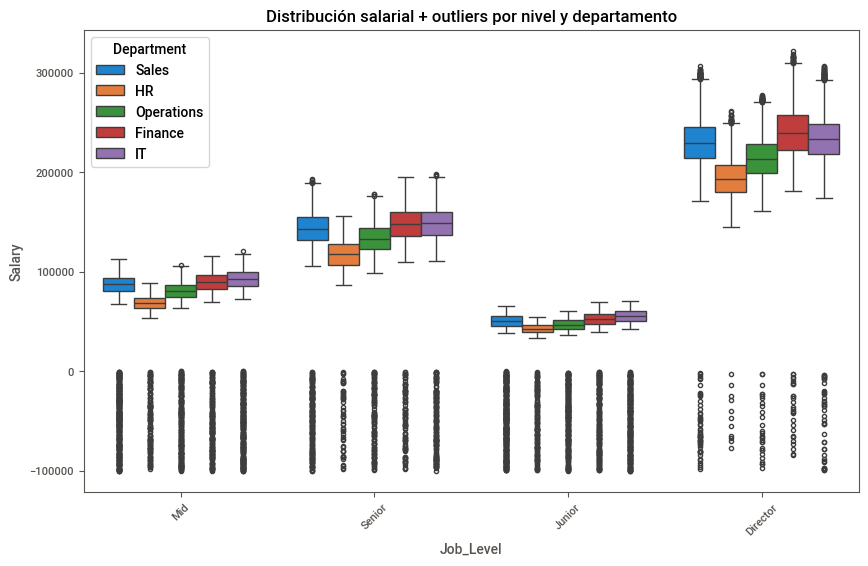

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Job_Level",
    y="Salary",
    hue="Department"
)

plt.xticks(rotation=45)
plt.title("Distribución salarial + outliers por nivel y departamento")
plt.show()

In [67]:
# Ana despues chusmea esto por ahi se pueda 
outliers.groupby(["Job_Level", "Department"]).size().sort_values(ascending=False)

Job_Level  Department
Mid        Sales         4229
           IT            3731
           Operations    2834
Senior     Sales         2787
           IT            2468
Mid        Finance       2037
Senior     Operations    1808
Junior     IT            1663
           Sales         1510
Mid        HR            1367
Senior     Finance       1351
Junior     Operations    1339
Director   Sales         1109
           IT             963
Junior     Finance        865
Senior     HR             811
Director   Operations     765
Junior     HR             681
Director   Finance        530
           HR             394
dtype: int64

7. Rangos
8. Relaciones
9. Claves
10. Distribución
11. Irrelevantes
12. Calidad / sesgos

# 4. Limpieza de datos (Data Cleaning)

In [15]:
# 1) 

# 5. Análisis exploratorio (EDA) - Analítica


In [16]:
df_grouped = df.groupby(['Department', 'Job_Title']).size().reset_index(name='Total_Employees')
df_grouped 

,Department,Job_Title,Total_Employees
0,Finance,Accountant,60125
1,Finance,CFO,59921
2,Finance,Finance Manager,59842
3,Finance,Financial Analyst,60017
4,Finance,Tax Specialist,60050
5,HR,HR Coordinator,40070
6,HR,HR Director,39887
7,HR,HR Manager,39989
8,HR,Recruiter,39698
9,HR,Talent Specialist,39848



Posible Organigrama
![Organigrama](Bosquejo_Organigrama.png)

# 6. Visualización de datos (Data Visualization)

# 7. Generación de insights (Conclusiones)